<a href="https://colab.research.google.com/github/isratrimii/Data-Mining/blob/main/Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error
from google.colab import drive

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the datasets
ratings_path = "/content/drive/MyDrive/Data Mining Lab/Copy of ratings.csv"
"movies_path = "/content/drive/MyDrive/Data Mining Lab/Copy of movies.csv"

In [4]:

ratings_df = pd.read_csv(ratings_path)
movies_df = pd.read_csv(movies_path)

print("Ratings Dataset Shape:", ratings_df.shape)
print("Movies Dataset Shape:", movies_df.shape)

Ratings Dataset Shape: (100836, 4)
Movies Dataset Shape: (9742, 3)


In [5]:
# Build User-Item Interaction Matrix using Pivot Table (Fast & Memory Efficient)
# Fill missing values with 0 representing unrated movies
user_item_matrix = ratings_df.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
print("\nUser-Item Matrix successfully created! Shape:", user_item_matrix.shape)


User-Item Matrix successfully created! Shape: (610, 9724)


In [6]:
# Compute Item Similarity Matrix using Cosine Similarity
# Transpose the user_item_matrix so columns represent items (movies)
item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

print("Item Similarity Matrix computed successfully! Shape:", item_similarity_df.shape)

Item Similarity Matrix computed successfully! Shape: (9724, 9724)


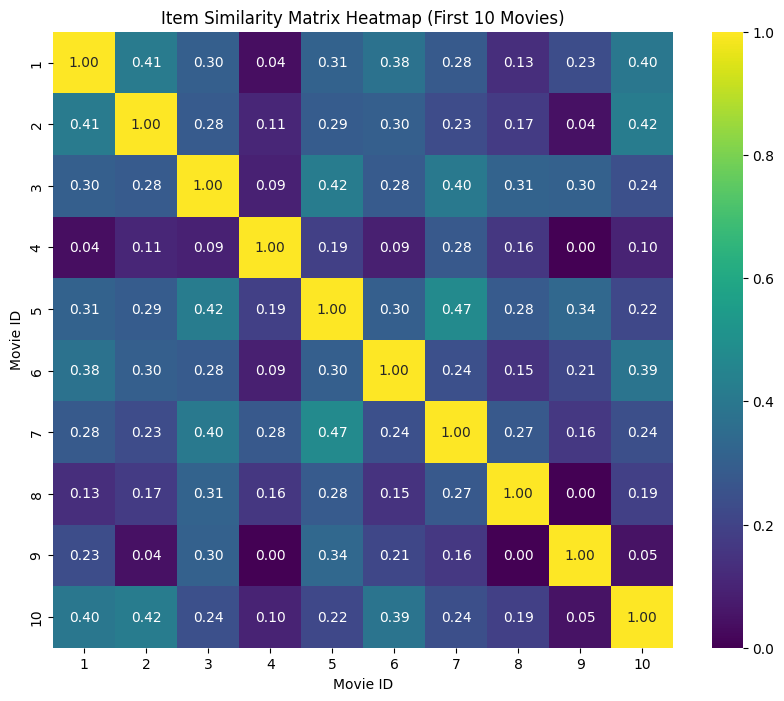

In [7]:
# Slice a 10x10 subsection of the item similarity matrix to visualize cleanly
plt.figure(figsize=(10, 8))
sns.heatmap(item_similarity_df.iloc[:10, :10], annot=True, cmap='viridis', fmt=".2f")
plt.title('Item Similarity Matrix Heatmap (First 10 Movies)')
plt.xlabel('Movie ID')
plt.ylabel('Movie ID')
plt.show()

In [8]:
def predict_ratings_and_get_top_n(user_id, n_recommendations=5):
    # Get ratings given by the target user
    user_ratings = user_item_matrix.loc[user_id]

    # Identify movies the user hasn't rated yet
    unrated_movies = user_ratings[user_ratings == 0].index
    rated_movies = user_ratings[user_ratings > 0].index

    predictions = {}

    # Predict rating for each unrated movie based on similarities to rated ones
    for movie_id in unrated_movies:
        similarity_scores = item_similarity_df[movie_id].loc[rated_movies]
        actual_ratings = user_ratings.loc[rated_movies]

        # Weighted Average Formula
        sum_sim = similarity_scores.sum()
        if sum_sim > 0:
            predicted_rating = np.dot(similarity_scores, actual_ratings) / sum_sim
        else:
            predicted_rating = 0

        predictions[movie_id] = predicted_rating

    # Sort predictions and fetch top-N
    sorted_predictions = sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]

    # Map Movie IDs to Titles
    recommendation_list = []
    for m_id, score in sorted_predictions:
        title = movies_df[movies_df['movieId'] == m_id]['title'].values[0]
        recommendation_list.append((title, round(score, 2)))

    return recommendation_list

# Show recommendations for at least 5 sample users as required
sample_users = user_item_matrix.index[:5]
print("--- GENERATING RECOMMENDATIONS FOR 5 USERS ---")
for idx, user in enumerate(sample_users, start=1):
    print(f"\nUser {idx} (User ID: {user}) Recommendations:")
    recs = predict_ratings_and_get_top_n(user_id=user, n_recommendations=5)
    for title, expected_score in recs:
        print(f" -> {title} (Predicted Rating: {expected_score})")

--- GENERATING RECOMMENDATIONS FOR 5 USERS ---

User 1 (User ID: 1) Recommendations:
 -> Entertaining Angels: The Dorothy Day Story (1996) (Predicted Rating: 5.0)
 -> Broken English (1996) (Predicted Rating: 5.0)
 -> Alvarez Kelly (1966) (Predicted Rating: 5.0)
 -> Come See the Paradise (1990) (Predicted Rating: 5.0)
 -> Circus (2000) (Predicted Rating: 5.0)

User 2 (User ID: 2) Recommendations:
 -> Deathgasm (2015) (Predicted Rating: 5.0)
 -> A Street Cat Named Bob (2016) (Predicted Rating: 5.0)
 -> Daddy's Home 2 (2017) (Predicted Rating: 5.0)
 -> Nobody Loves Me (Keiner liebt mich) (1994) (Predicted Rating: 4.5)
 -> Bread and Chocolate (Pane e cioccolata) (1973) (Predicted Rating: 4.5)

User 3 (User ID: 3) Recommendations:
 -> 1-900 (06) (1994) (Predicted Rating: 5.0)
 -> Dear God (1996) (Predicted Rating: 5.0)
 -> Fighting Temptations, The (2003) (Predicted Rating: 5.0)
 -> Beyond Borders (2003) (Predicted Rating: 5.0)
 -> Big Empty, The (2003) (Predicted Rating: 5.0)

User 4 (User

In [9]:
# To evaluate, we mask some actual ratings, predict them, and check the error rate
def evaluate_system_mae(num_test_users=10):
    test_users = user_item_matrix.index[:num_test_users]
    actual_list = []
    predicted_list = []

    for user_id in test_users:
        user_ratings = user_item_matrix.loc[user_id]
        rated_movies = user_ratings[user_ratings > 0].index

        # Test on up to 5 rated movies per user
        for movie_id in rated_movies[:5]:
            # Temporarily isolate other ratings to simulate prediction
            other_rated_movies = rated_movies.drop(movie_id)
            if len(other_rated_movies) == 0: continue

            similarity_scores = item_similarity_df[movie_id].loc[other_rated_movies]
            actual_ratings = user_ratings.loc[other_rated_movies]

            sum_sim = similarity_scores.sum()
            if sum_sim > 0:
                pred = np.dot(similarity_scores, actual_ratings) / sum_sim
                actual_list.append(user_ratings[movie_id])
                predicted_list.append(pred)

    mae = mean_absolute_error(actual_list, predicted_list)
    return mae

mae_score = evaluate_system_mae()
print(f"\nSystem Evaluation - Mean Absolute Error (MAE): {round(mae_score, 4)}")


System Evaluation - Mean Absolute Error (MAE): 0.7115
